# Breakout 아타리 게임 플레이 (테스트)
- 프로그램 7-6 참고
- `fbreakout.keras`에서 학습된 신경망 불러오기
  : fbreakout.keras : breakout_train.ipynb을 실행하면 DQN으로 학습된 신경망의 가중치가 저장되는 파일입니다.
- `ALE/Breakout-v5` 환경에서 게임 플레이

In [6]:
import gymnasium as gym
import numpy as np
from tensorflow.keras.models import load_model
from collections import deque
import cv2 as cv
import ale_py
from IPython.display import display, clear_output
from PIL import Image

consecutive = 4  
# 4장의 연속 영상으로 상태 표현
rows = 84
# 신경망 입력 영상 높이 (84×84로 축소)
cols = 84
# 신경망 입력 영상 너비
# actions = [0,2,3]  # 0(위치 유지), 2(오른쪽 이동), 3(왼쪽 이동)
actions = [0,1,2,3] # 0:정지, 1:FIRE(공 발사), 2:오른쪽, 3:왼쪽


In [7]:
def preprocess(img):
    """게임 화면 전처리: 210×160×3 컬러 → 84×84×1 흑백 (학습 시와 동일한 전처리)"""
    return cv.resize(
        cv.cvtColor(img[30:-10, 5:-5, :],
                    cv.COLOR_BGR2GRAY),
                    dsize=(rows, cols)).reshape(rows, cols, 1)
    # img[30:-10, 5:-5] : 상단 점수판 · 하단 여백 · 좌우 경계 제거(crop)

In [22]:
import time

def play_match(env, max_steps=1000000, delay=0.03):
    obs, info = env.reset()
    # 게임 시작 시 초기 화면 관측
    obs, _, _, _, info = env.step(1)  
    # FIRE: Breakout은 공 발사 후 게임 시작
    lives = info["lives"]
    # 현재 목숨 수 기록

    imem = deque(maxlen = consecutive)  
    # imem은 최대 길이 4인 데큐(deque)으로, 최근 4장의 프레임을 저장하여 상태 표현
    for j in range(consecutive): imem.append(preprocess(obs))
    # 게임 시작 시 초기 상태 구성: 4장의 동일한 프레임으로 초기 상태 표현
    s = np.transpose(np.squeeze(np.asarray(imem)), (1,2,0))
    # 상태 s는 (4,84,84) 형태 → 신경망 입력은 (84,84,4) 형태로 변환

    for _ in range(max_steps):
    # 현재 상태를 신경망에 넣어 각 행동의 Q값 계산 후 최대 Q값 행동 선택 (탐욕 정책)
        y_hat = model(s.reshape(1, rows, cols, consecutive))[0]
        # 신경망에 현재 상태 s를 입력하여 각 행동의 Q값 계산 → y_hat은 4개의 Q값 벡터
        a = np.argmax(y_hat)
        # 최대 Q값 행동 a 선택 → a는 0(정지), 1(FIRE), 2(오른쪽), 3(왼쪽) 중 하나
        obs, reward, terminated, truncated, info = env.step(actions[a])
        # 행동 a를 환경에 적용 → 다음 프레임 obs 관측, 보상 reward 획득, 종료 여부 terminated/truncated 확인

        # 목숨을 잃을 때마다 자동으로 FIRE를 눌러 공을 재발사
        if info["lives"] < lives:
            lives = info["lives"]
            obs, _, _, _, _ = env.step(1)  
            # FIRE: 새 공 발사

        imem.append(preprocess(obs))
        # 새 프레임 추가 → imem에는 최대 4개의 프레임이 저장되고, 가장 오래된 프레임은 자동으로 제거됨
        s = np.transpose(np.squeeze(np.asarray(imem)), (1,2,0))
        # 다음 상태로 s 업데이트→ 새 프레임이 추가된 imem에서 4장의 프레임을 (84,84,4) 형태로 변환하여 상태 s로 사용

        clear_output(wait=True)
        display(Image.fromarray(env.render()))
        # 게임 화면 출력 → env.render()로 현재 게임 화면(RGB 배열)을 PIL 이미지로 변환하여 노트북에 표시
        time.sleep(delay)
        # delay 초 대기 → 화면 갱신 속도 조절 (기본 0.03초)
        # cv.waitKey(30)에 대응

        if terminated or truncated:
        # 게임 종료(목숨 소진 또는 타임아웃) 시 경기 종료, 루프 탈출
            break


```
def play_match(env):
    obs, info = env.reset()
    # 게임 시작 시 초기 화면 관측
    obs, _, _, _, _ = env.step(1)  
    # FIRE: Breakout은 공 발사 후 게임 시작

    imem = deque(maxlen=consecutive)  
    # imem은 최대 길이 4인 데큐(deque)으로, 최근 4장의 프레임을 저장하여 상태 표현
    for j in range(consecutive): imem.append(preprocess(obs))
    # 게임 시작 시 초기 상태 구성: 4장의 동일한 프레임으로 초기 상태 표현
    s = np.transpose(np.squeeze(np.asarray(imem)),(1,2,0))
    # 상태 s는 (4,84,84) 형태 → 신경망 입력은 (84,84,4) 형태로 변환

    while True:
    # 현재 상태를 신경망에 넣어 각 행동의 Q값 계산 후 최대 Q값 행동 선택 (탐욕 정책)
        y_hat = model(s.reshape(1,rows,cols,consecutive))[0]
        # 신경망에 현재 상태 s를 입력하여 각 행동의 Q값 계산 → y_hat은 3개의 Q값 벡터
        a = np.argmax(y_hat)
        # 최대 Q값 행동 a 선택 → a는 0(위치 유지), 2(오른쪽 이동), 3(왼쪽 이동) 중 하나
        obs,reward,terminated,truncated,info = env.step(actions[a])
        # 행동 a를 환경에 적용 → 다음 프레임 obs 관측, 보상 reward 획득, 종료 여부 terminated/truncated 확인
        imem.append(preprocess(obs))
        # 새 프레임 추가 → imem에는 최대 4개의 프레임이 저장되고, 가장 오래된 프레임은 자동으로 제거됨
        s = np.transpose(np.squeeze(np.asarray(imem)),(1,2,0))
        # 다음 상태로 s 업데이트→ 새 프레임이 추가된 imem에서 4장의 프레임을 (84,84,4) 형태로 변환하여 상태 s로 사용

        cv.imshow("animation", 
                  cv.cvtColor(env.render(),
                              cv.COLOR_BGR2RGB))
        # 게임 화면 출력 → env.render()로 현재 게임 화면을 RGB 이미지로 얻어와 OpenCV로 표시     
        key = cv.waitKey(10)
        # 키 입력 대기 → 10ms마다 키 입력 확인
        if key == ord("q"): break
        # 현재 게임 화면 출력 (q키를 누르면 종료)

        if terminated or truncated:
        # 게임 종료(목숨 소진 또는 타임아웃) 시 경기 종료, 루프 탈출
            break
```

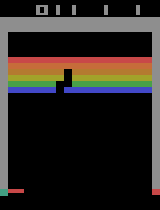

In [27]:
gym.register_envs(ale_py)
# ALE/Breakout-v5 환경 등록 → gym.make()로 환경 생성 가능
model = load_model("fbreakout.keras", compile = False)
# 모델 불러오기 → 학습된 DQN 모델을 "fbreakout.keras" 파일에서 로드하여 model 변수에 저장
# compile=False: 저장된 옵티마이저 상태를 무시하여 Keras 버전 호환성 문제 해결

env = gym.make("ALE/Breakout-v5",
               render_mode = "rgb_array")
# Breakout환경 생성 → "ALE/Breakout-v5" 환경을 생성하고, 렌더링 모드를 "rgb_array"로 설정

play_match(env)
# 게임 플레이
env.close()
# 게임 종료 → 환경 자원 해제

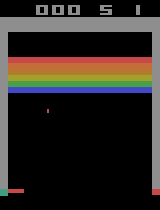
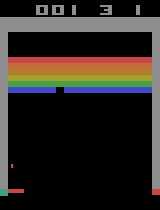
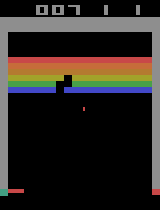
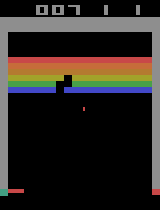
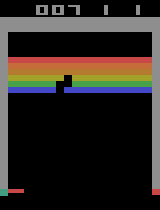